# Analisis Klasterisasi Kabupaten/Kota di Jawa Timur Berdasarkan Indikator Sosial-Ekonomi

**Penulis:** [Ramadhan Adi Nugraha]

**Deskripsi Singkat:** 
Notebook ini berisi proses eksplorasi data, reduksi dimensi menggunakan PCA, dan pemodelan klasterisasi (K-Means & Agglomerative) untuk memetakan tingkat kesejahteraan masyarakat di Provinsi Jawa Timur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy.stats import chi2
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import mahalanobis
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
silhouette_score,
calinski_harabasz_score,
davies_bouldin_score
)

In [2]:
df = pd.read_excel("Dataset Clustering.xlsx")
df.head()

,Kabupaten/Kota Se Jawa Timur,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
0,Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
1,Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
2,Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
3,Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
4,Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


In [3]:
nama_kabupaten = df['Kabupaten/Kota Se Jawa Timur']
data_cluster = df.drop(columns=['Kabupaten/Kota Se Jawa Timur'])
print("Data setelah atribut No. dan Kabupaten dihapus:")
display(data_cluster.head())
print("Summary statistik:")
display(data_cluster.describe())

Data setelah atribut No. dan Kabupaten dihapus:


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
0,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
1,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
2,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
3,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
4,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


Summary statistik:


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
count,38.000000,38.000000,38.000000,38.000000,38.000000,3.800000e+01,3.800000e+01,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,3.653947,69.648158,50.261316,56521.842105,49.738684,2.165218e+06,5.381566e+05,61261.763158,2.631579,19.567632,...,69.129737,76.100789,76.478684,0.324921,0.383421,7.798158,72.950263,17.117632,252129.838947,44052.152632
std,1.080297,3.470277,5.770744,96510.907508,5.770744,4.774494e+05,3.303333e+05,48057.401520,1.684275,9.250350,...,14.276156,16.168388,19.276304,0.035604,0.235742,1.615808,4.697626,4.092143,219490.106766,69027.998073
min,0.910000,63.440000,36.600000,5236.000000,37.460000,1.562340e+06,6.683300e+04,7596.000000,0.320000,7.040000,...,41.820000,32.100000,20.090000,0.267000,0.050000,4.550000,64.750000,8.290000,3565.880000,4832.900000
25%,2.890000,66.890000,46.675000,19428.000000,46.297500,1.834726e+06,3.789848e+05,34203.750000,1.720000,13.532500,...,57.682500,67.882500,70.462500,0.304250,0.230000,6.852500,69.360000,15.117500,91470.405000,13180.725000
50%,3.590000,69.210000,50.375000,24716.000000,49.625000,2.004876e+06,5.127485e+05,50829.000000,2.555000,18.135000,...,66.920000,78.485000,82.335000,0.318500,0.335000,7.460000,72.315000,17.050000,223432.505000,22979.350000
75%,4.225000,72.037500,53.702500,43596.750000,53.325000,2.422863e+06,6.315382e+05,71907.250000,3.112500,23.377500,...,82.162500,88.830000,89.772500,0.338750,0.430000,8.967500,76.065000,19.630000,343116.225000,53733.700000
max,5.880000,79.620000,62.540000,574173.000000,63.400000,3.405633e+06,1.426945e+06,228815.000000,7.300000,45.600000,...,96.280000,98.930000,99.070000,0.421000,1.080000,11.130000,82.760000,27.140000,839724.430000,410879.300000


## ANALISIS KORELASI
------------

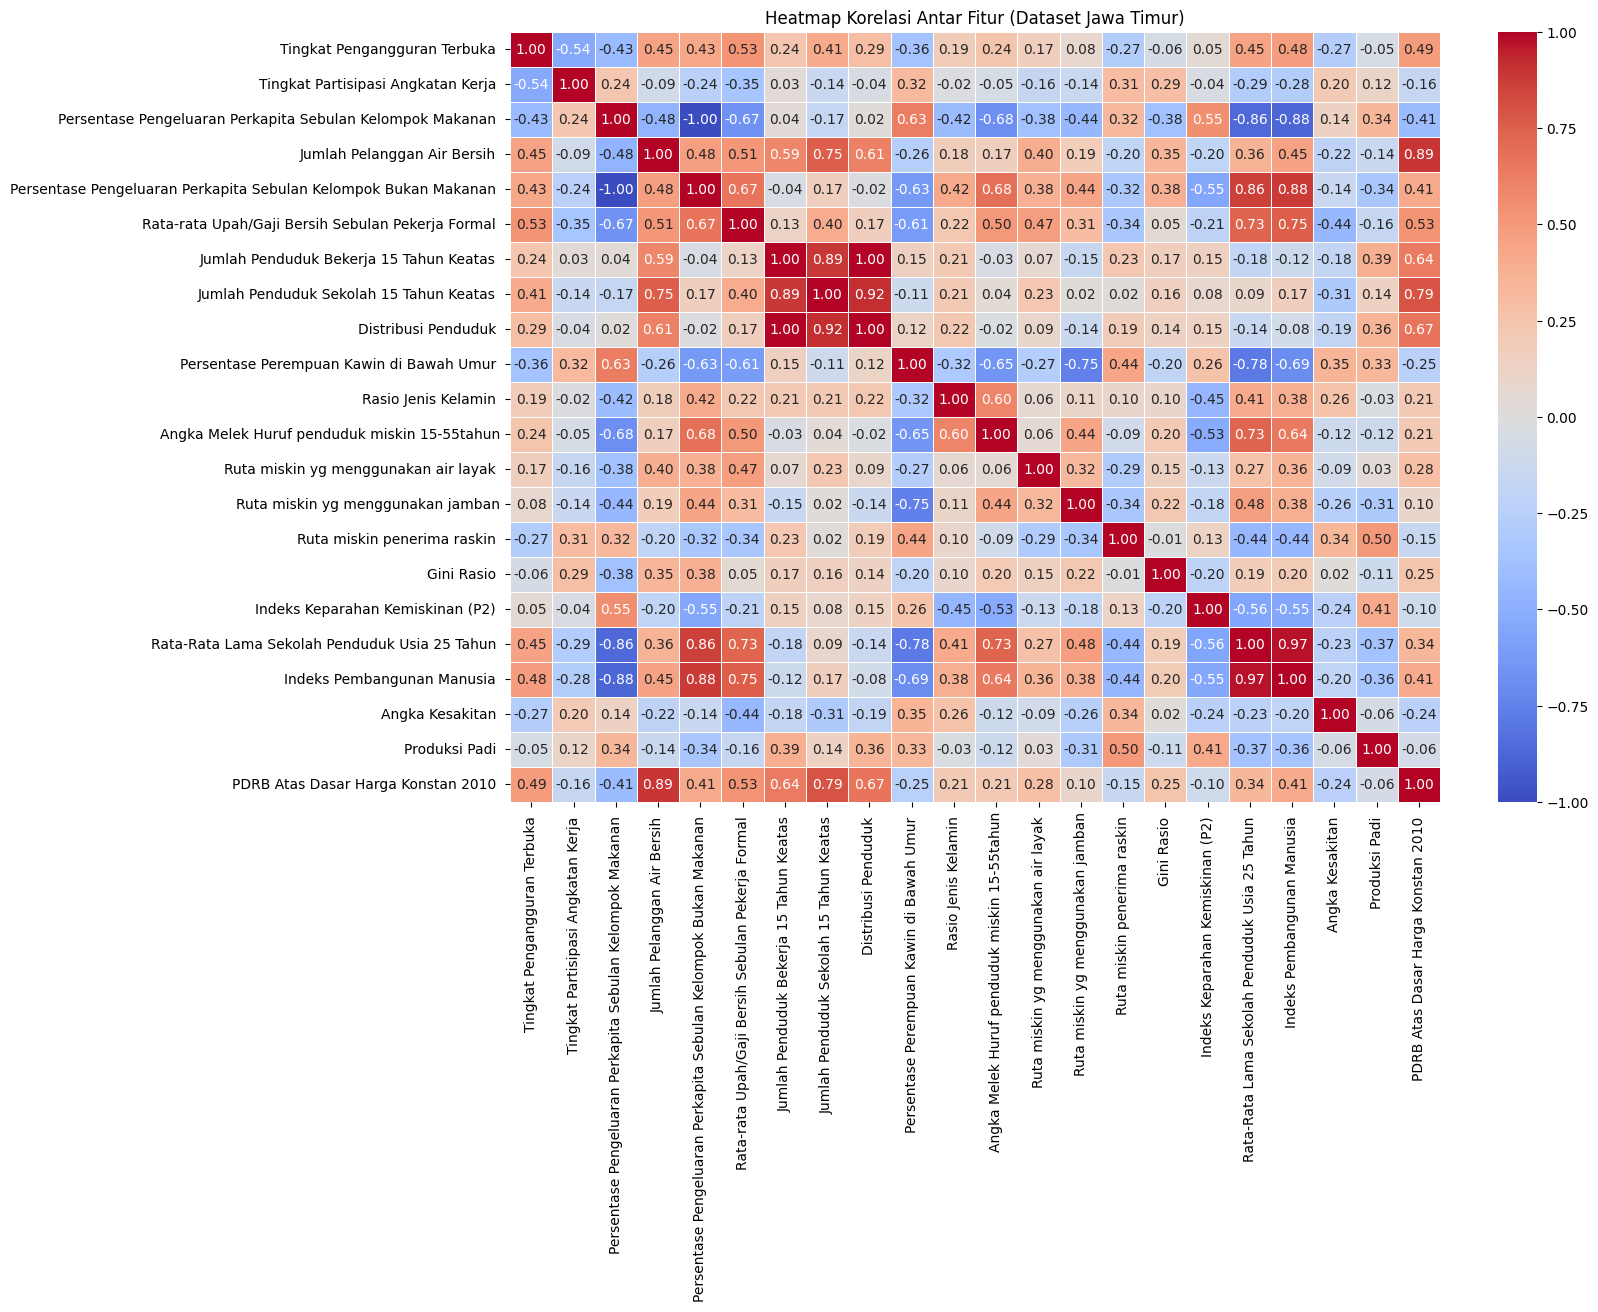

In [4]:
# Menghitung matriks korelasi
correlation_matrix = data_cluster.corr(method='pearson')

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur (Dataset Jawa Timur)')
plt.show()

In [5]:
# Menghitung korelasi
corr = data_cluster.corr()

# Mengambil pasangan dengan korelasi di atas 0.7 secara lebih rapi
def get_clean_high_corr(df, threshold=0.7):
    # Buat tabel korelasi menjadi format panjang (long format)
    sol = (df.corr().stack()
             .reset_index()
             .rename(columns={0: 'Korelasi', 'level_0': 'Atribut_1', 'level_1': 'Atribut_2'}))
    
    # Hapus korelasi antar variabel yang sama (nilai 1.0)
    sol = sol[sol['Atribut_1'] != sol['Atribut_2']]
    
    # Ambil yang di atas threshold (absolut)
    sol = sol[sol['Korelasi'].abs() > threshold]
    
    # Hapus duplikat pasangan (A-B dan B-A)
    sol['key'] = sol.apply(lambda x: "-".join(sorted([x['Atribut_1'], x['Atribut_2']])), axis=1)
    sol = sol.drop_duplicates('key').drop(columns='key')
    
    return sol.sort_values(by='Korelasi', ascending=False)

# Tampilkan hasil yang sudah bersih
clean_list = get_clean_high_corr(data_cluster)
print("--- RINGKASAN ATRIBUT YANG SALING BERKAITAN ERAT ---")
print(clean_list.to_string(index=False))

--- RINGKASAN ATRIBUT YANG SALING BERKAITAN ERAT ---
                                                       Atribut_1                                                        Atribut_2  Korelasi
                        Jumlah Penduduk Bekerja 15 Tahun Keatas                                              Distribusi Penduduk   0.995063
                  Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun                                       Indeks Pembangunan Manusia   0.972686
                        Jumlah Penduduk Sekolah 15 Tahun Keatas                                              Distribusi Penduduk   0.915560
                                    Jumlah Pelanggan Air Bersih                               PDRB Atas Dasar Harga Konstan 2010   0.891131
                        Jumlah Penduduk Bekerja 15 Tahun Keatas                          Jumlah Penduduk Sekolah 15 Tahun Keatas   0.886617
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan                                       Indek

## Ringkasan Atribut yang Dihapus:
    1. Persentase Pengeluaran Makanan (Redundan dengan Pengeluaran Bukan Makanan)
    2. Jumlah Penduduk Bekerja 15 Tahun Keatas (Redundan dengan Distribusi Penduduk)
    3. Jumlah Penduduk Sekolah 15 Tahun Keatas (Redundan dengan Distribusi Penduduk)
    4. Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun (Redundan dengan IPM)
    5. Produksi Padi (Diwakili PDRB sebagai indikator ekonomi makro)

Jumlah variabel awal: 22
Jumlah variabel sekarang: 17

Daftar variabel yang digunakan untuk clustering:
['Tingkat Pengangguran Terbuka ', 'Tingkat Partisipasi Angkatan Kerja ', 'Jumlah Pelanggan Air Bersih ', 'Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan ', 'Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal ', 'Distribusi Penduduk ', 'Persentase Perempuan Kawin di Bawah Umur ', 'Rasio Jenis Kelamin ', 'Angka Melek Huruf penduduk miskin 15-55tahun', 'Ruta miskin yg menggunakan air layak ', 'Ruta miskin yg menggunakan jamban', 'Ruta miskin penerima raskin ', 'Gini Rasio ', 'Indeks Keparahan Kemiskinan (P2) ', 'Indeks Pembangunan Manusia ', 'Angka Kesakitan ', 'PDRB Atas Dasar Harga Konstan 2010 ']


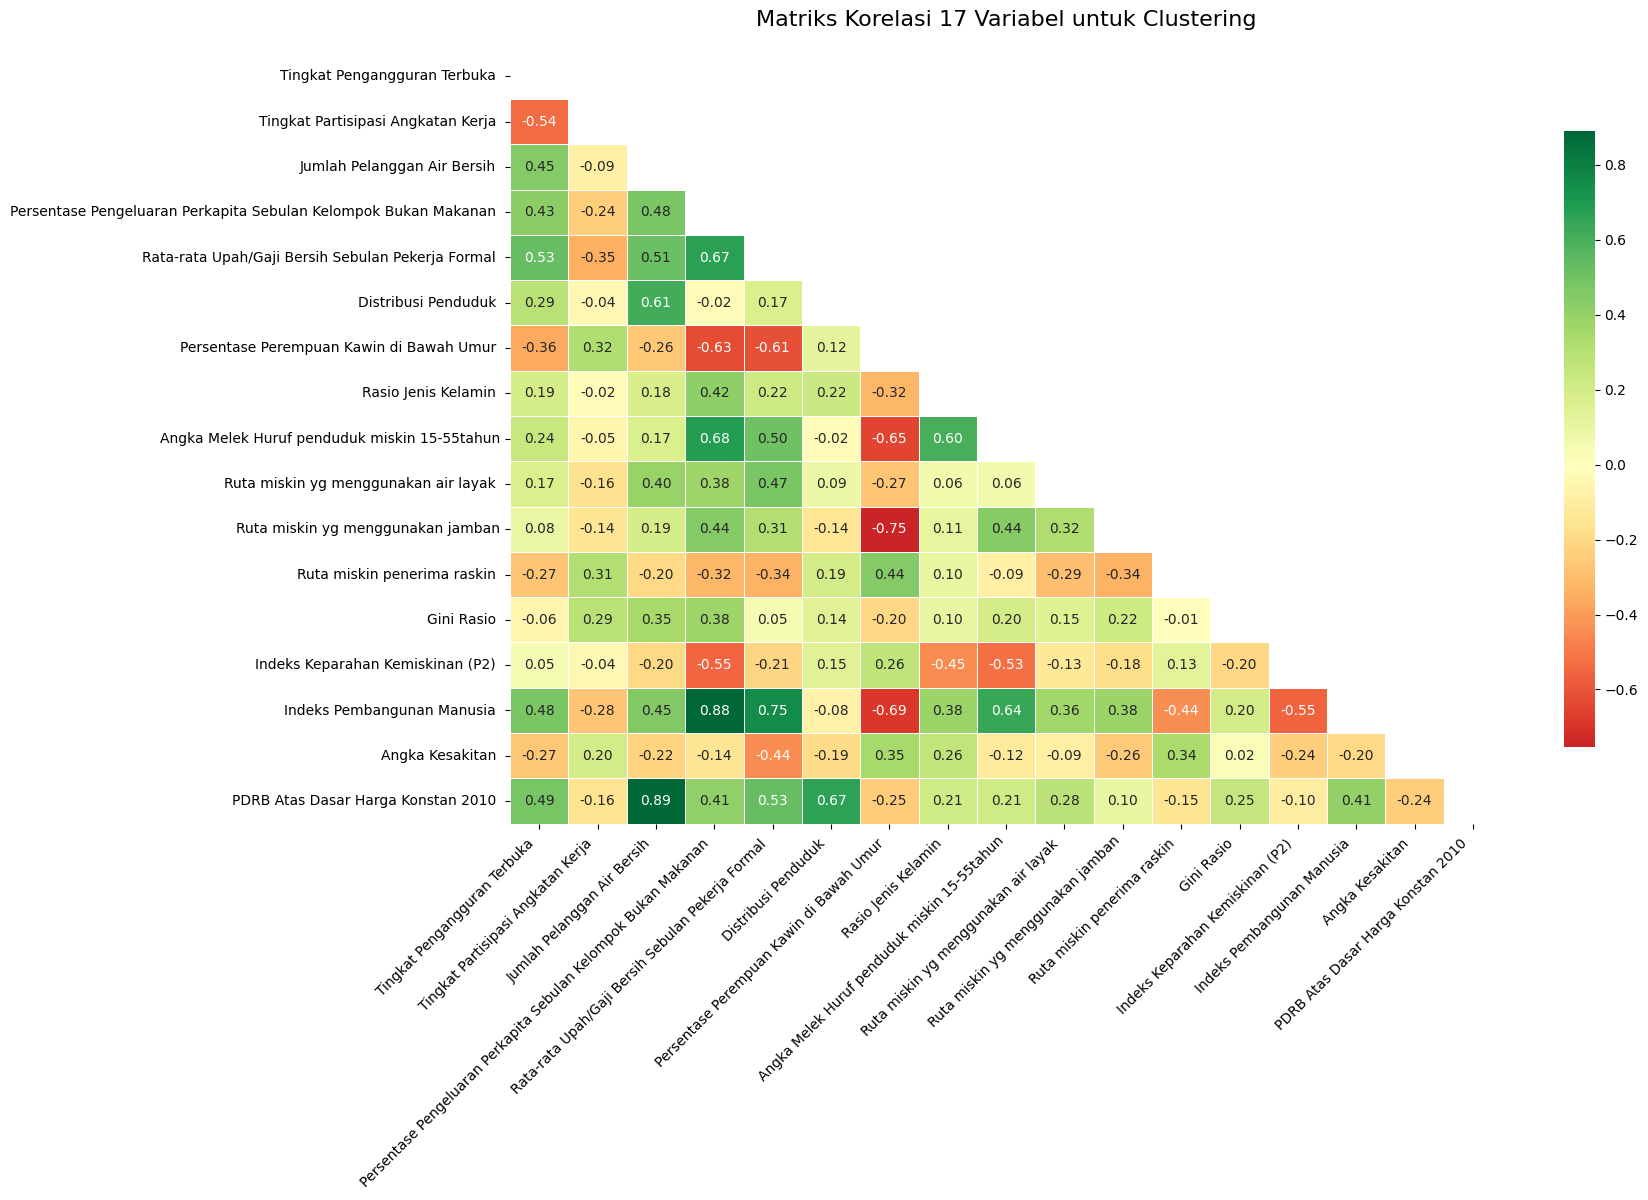

Jumlah variabel yang digunakan sekarang: 17


In [6]:
# Daftar kolom yang akan dihapus
kolom_dihapus = [
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan ',
    'Jumlah Penduduk Bekerja 15 Tahun Keatas ',
    'Jumlah Penduduk Sekolah 15 Tahun Keatas ',
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
    'Produksi Padi '
]

# Menghapus kolom dari data_cluster
data_final = data_cluster.drop(columns=kolom_dihapus)

print("Jumlah variabel awal:", data_cluster.shape[1])
print("Jumlah variabel sekarang:", data_final.shape[1])
print("\nDaftar variabel yang digunakan untuk clustering:")
print(data_final.columns.tolist())

# Membuat dataset baru dengan 17 variabel
data_final = data_cluster.drop(columns=kolom_dihapus)

# Menghitung Matriks Korelasi
corr_final = data_final.corr()

# Visualisasi dengan Heatmap Segitiga
plt.figure(figsize=(16, 10))

# Membuat mask untuk menyembunyikan segitiga atas agar tidak redundan
mask = np.triu(np.ones_like(corr_final, dtype=bool))

# Membuat Heatmap
heatmap = sns.heatmap(corr_final, 
                      mask=mask, 
                      annot=True, 
                      fmt=".2f", 
                      cmap='RdYlGn', 
                      center=0,
                      linewidths=.5, 
                      cbar_kws={"shrink": .8})

plt.title('Matriks Korelasi 17 Variabel untuk Clustering', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

# Menampilkan info jumlah kolom untuk memastikan sudah 17
print(f"Jumlah variabel yang digunakan sekarang: {data_final.shape[1]}")

# Visualisasi Histogram & Boxplot Distribusi Data Per Atribut
-----

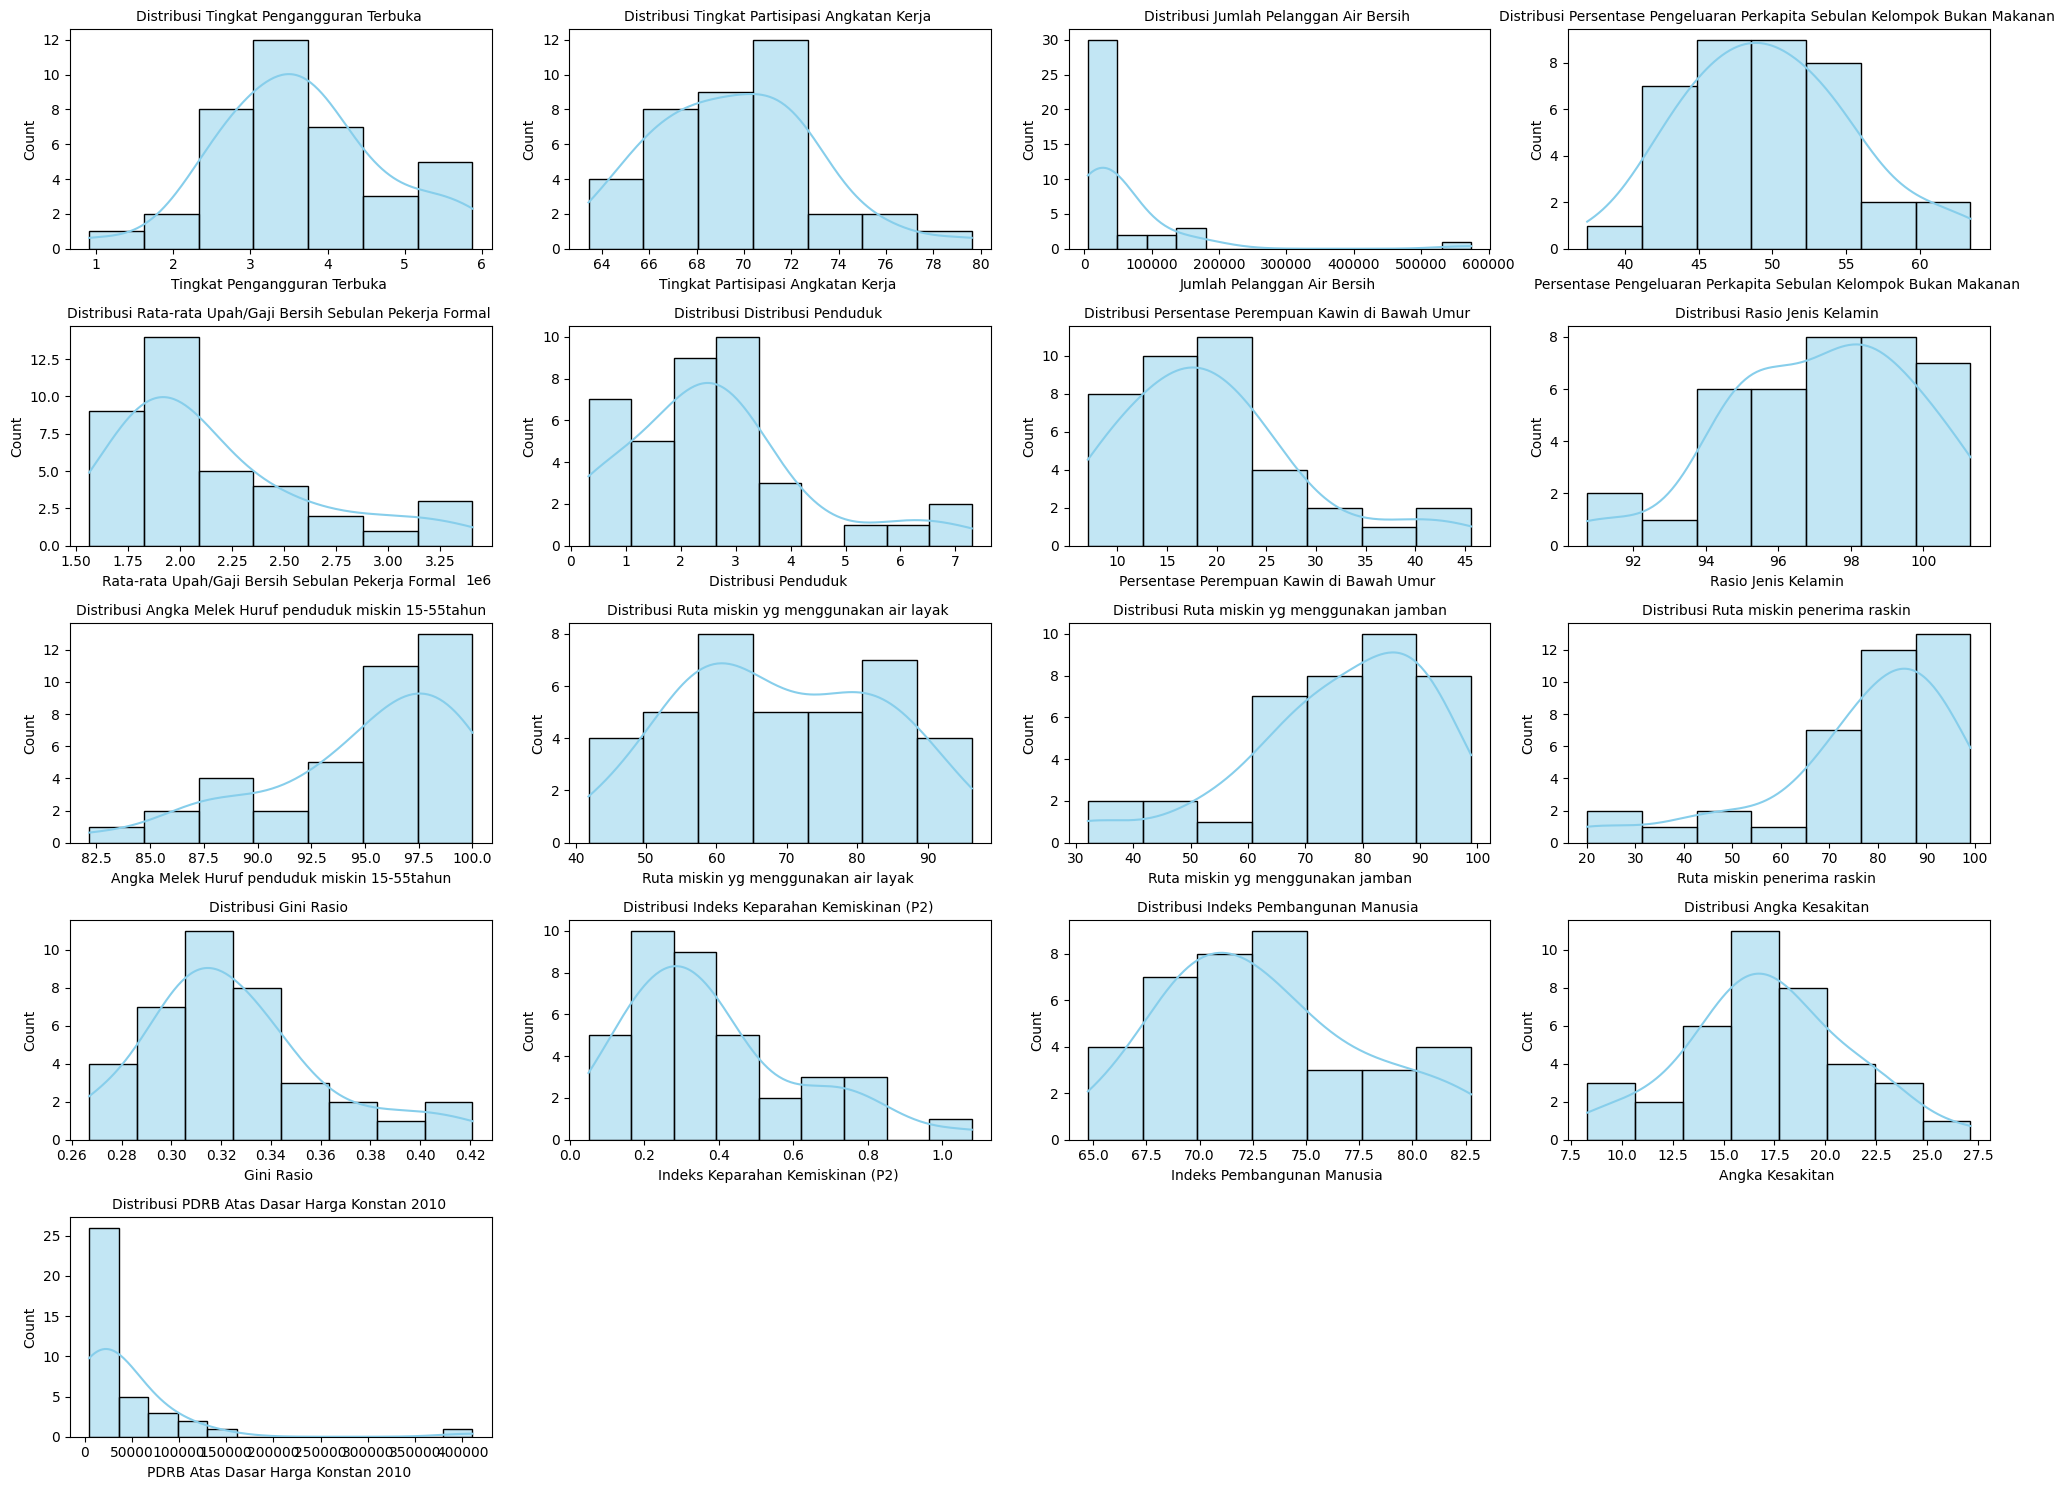

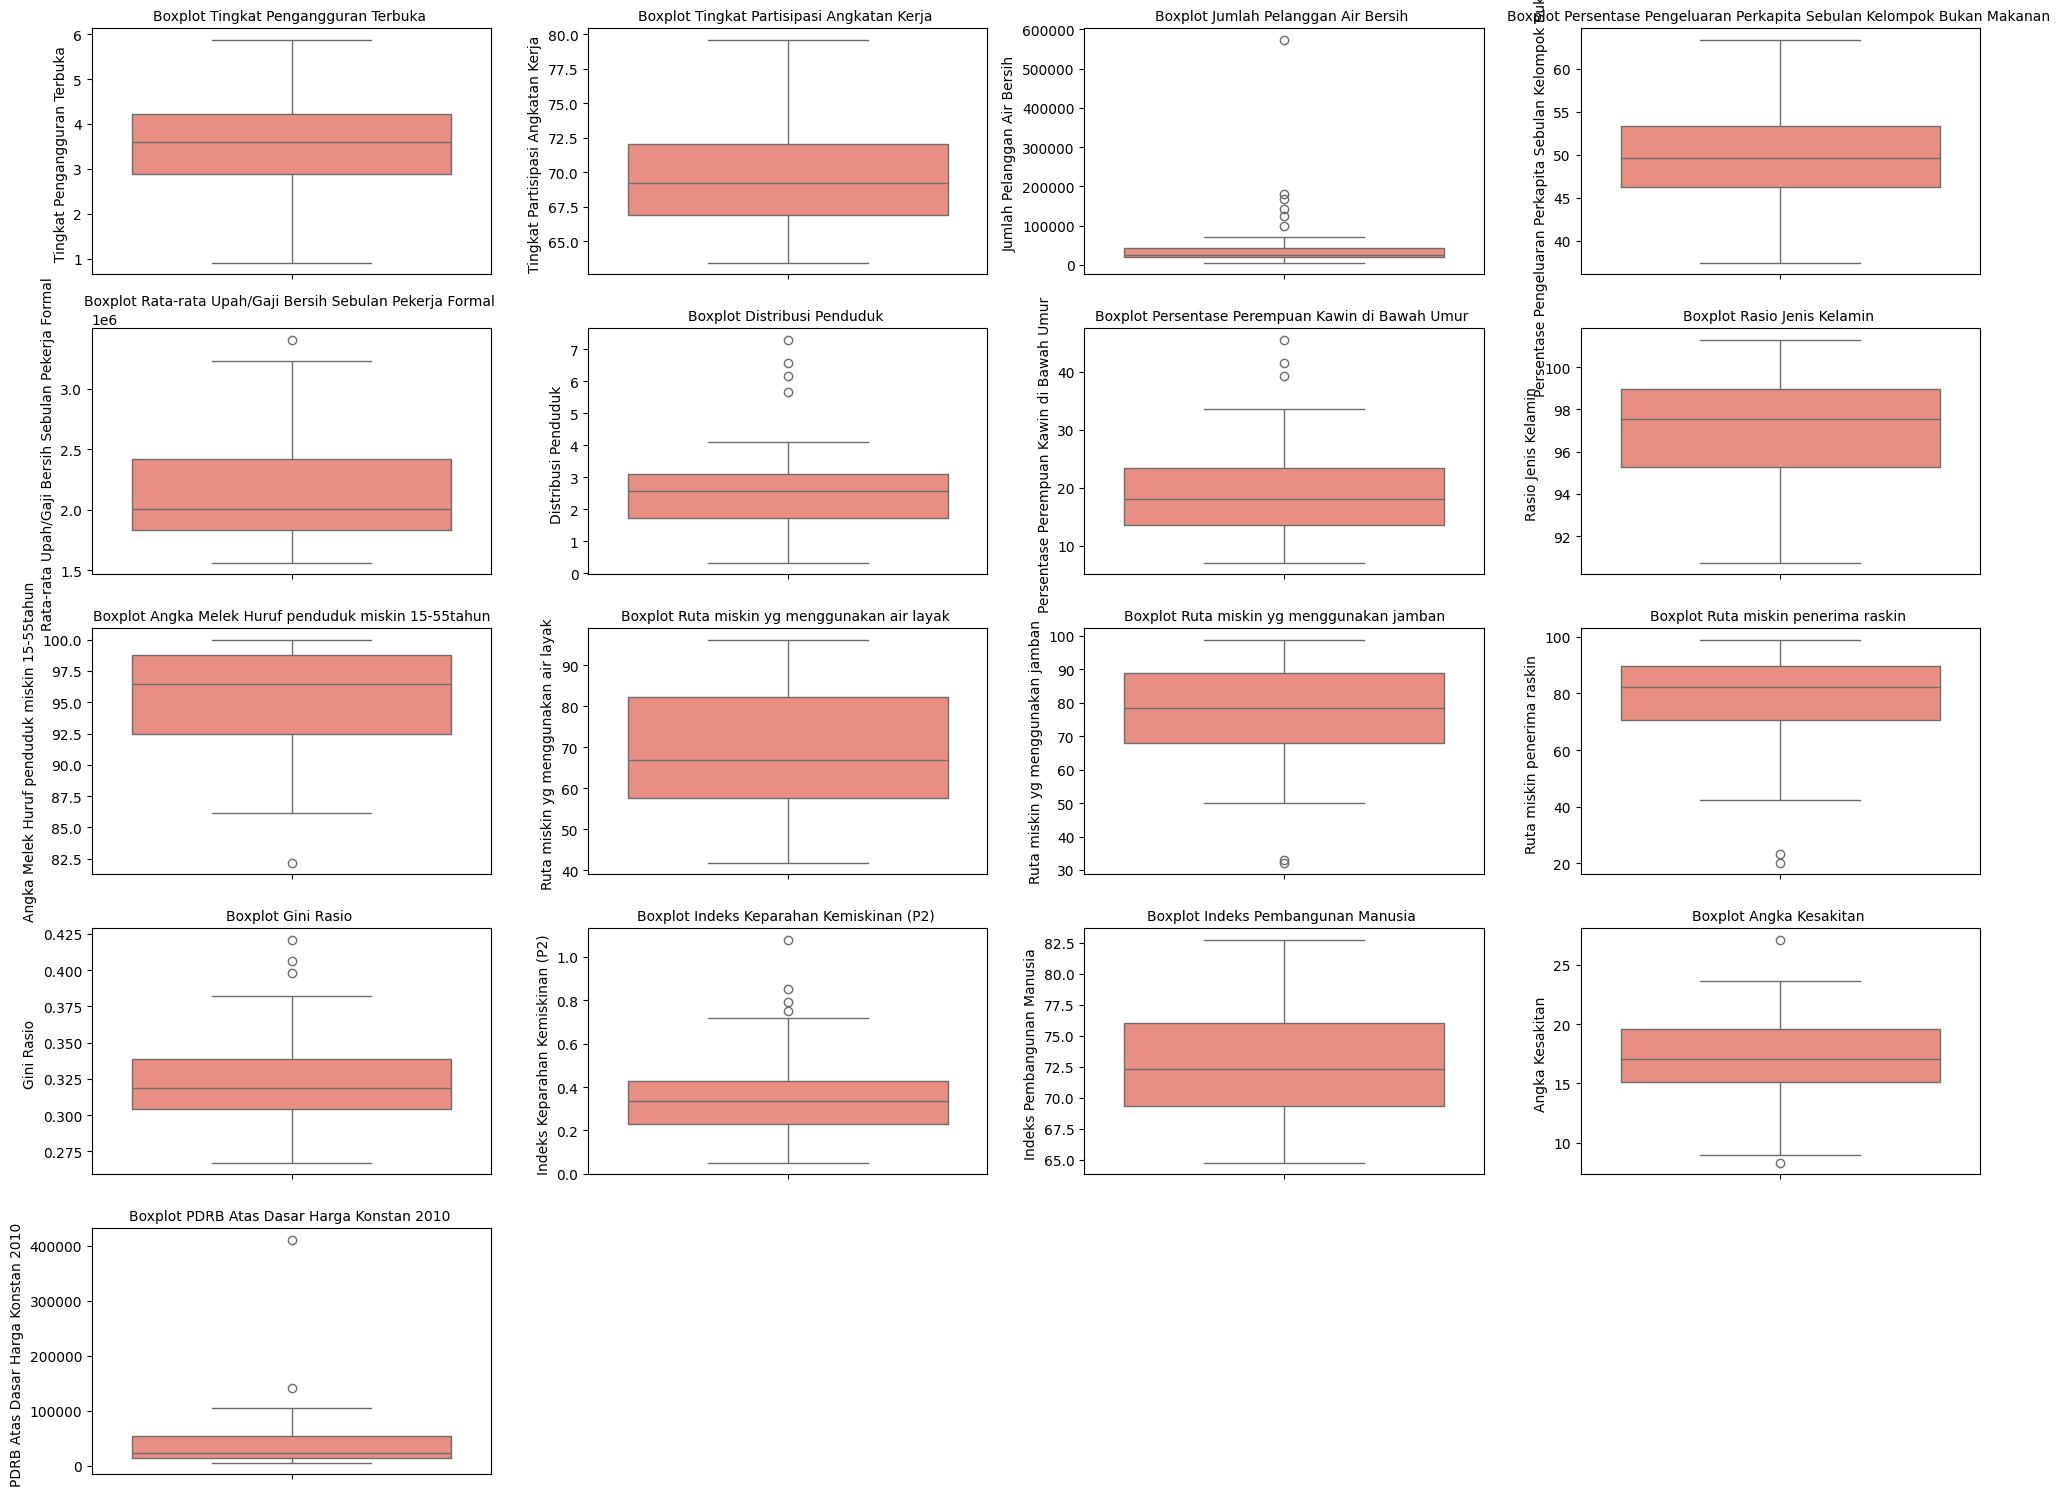

In [7]:
# 1. Menyiapkan data_final (17 variabel)
kolom_dihapus = [
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan ',
    'Jumlah Penduduk Bekerja 15 Tahun Keatas ',
    'Jumlah Penduduk Sekolah 15 Tahun Keatas ',
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
    'Produksi Padi '
]
data_final = data_cluster.drop(columns=kolom_dihapus)

# 2. Visualisasi Histogram (Untuk melihat bentuk distribusi)
plt.figure(figsize=(20, 15))
for i, col in enumerate(data_final.columns):
    plt.subplot(5, 4, i+1)
    sns.histplot(data_final[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}', fontsize=10)
    plt.tight_layout()
plt.show()

# 3. Visualisasi Boxplot (Untuk melihat pencilan/outlier)
plt.figure(figsize=(20, 15))
for i, col in enumerate(data_final.columns):
    plt.subplot(5, 4, i+1)
    sns.boxplot(y=data_final[col], color='salmon')
    plt.title(f'Boxplot {col}', fontsize=10)
    plt.tight_layout()
plt.show()

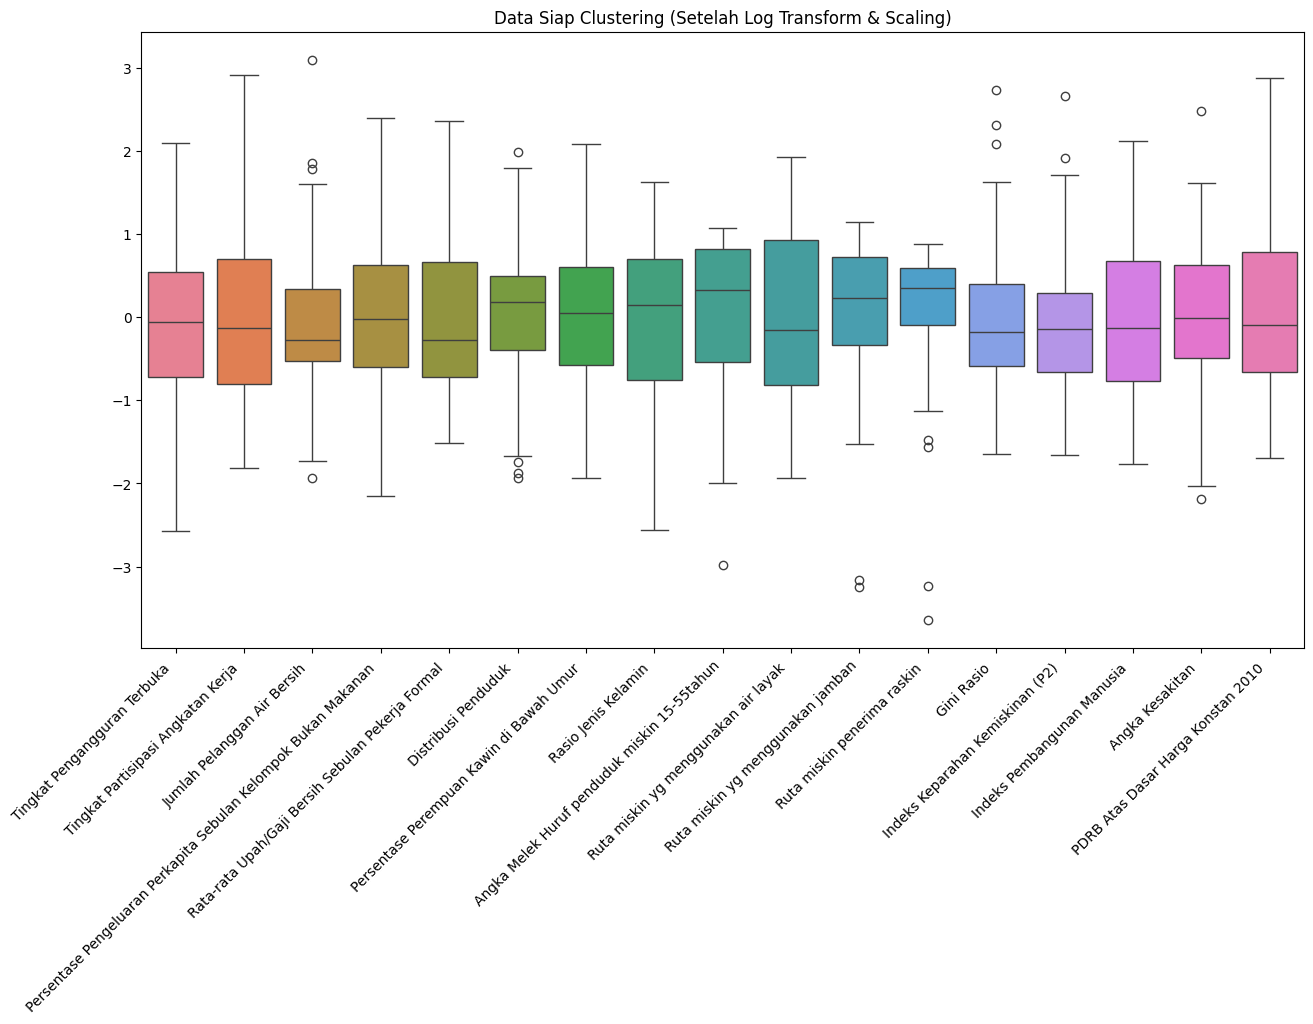

Dataset sekarang sudah bersih, simetris, dan memiliki skala yang setara.


In [8]:
# Menyiapkan Dataset (Menghapus 5 variabel redundan)
kolom_dihapus = [
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan ',
    'Jumlah Penduduk Bekerja 15 Tahun Keatas ',
    'Jumlah Penduduk Sekolah 15 Tahun Keatas ',
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
    'Produksi Padi '
]
data_final = data_cluster.drop(columns=kolom_dihapus)

# Tahap Transformasi Log (Metode Modul Anda)
# Untuk merapikan variabel yang sangat miring (skewed)
data_transform = data_final.copy()
for col in data_transform.columns:
    if abs(data_transform[col].skew()) > 1:
        data_transform[col] = np.log1p(data_transform[col])

# Tahap Scaling Akhir (StandardScaler)
# Menyamakan skala agar mean=0 dan std=1
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(data_transform)

# Mengembalikan ke bentuk DataFrame agar rapi
data_ready = pd.DataFrame(data_scaled_array, columns=data_transform.columns)

# Visualisasi Hasil Akhir
plt.figure(figsize=(15, 8))
sns.boxplot(data=data_ready)
plt.xticks(rotation=45, ha='right')
plt.title('Data Siap Clustering (Setelah Log Transform & Scaling)')
plt.show()

print("Dataset sekarang sudah bersih, simetris, dan memiliki skala yang setara.")

# Uji Outlier Secara Multivariate Menggunakan Mahalonobis
--------------

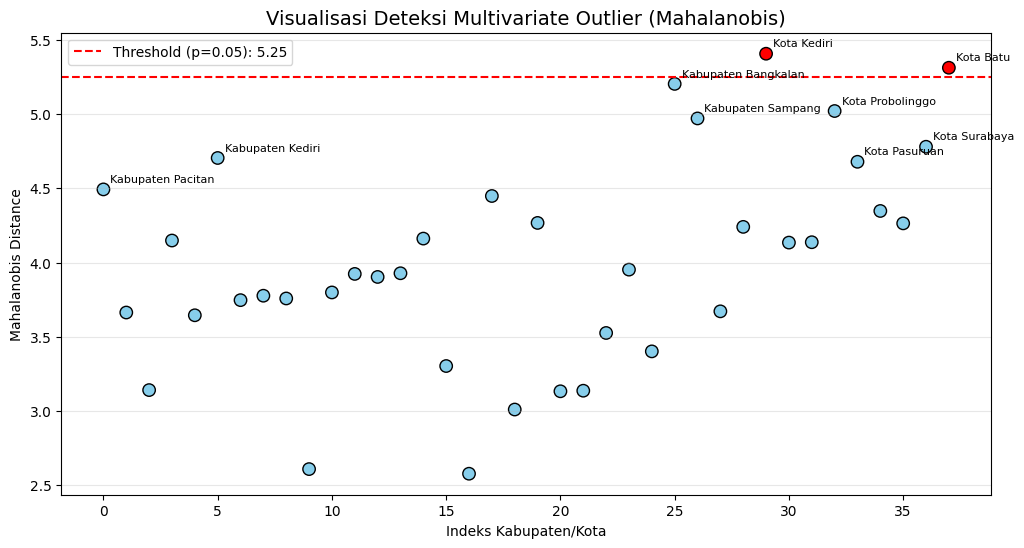

Batas Outlier: 5.2523
Jumlah Outlier Terdeteksi: 2


,Kabupaten,MD,Status
0,Kabupaten Pacitan,4.493124,Normal
1,Kabupaten Ponorogo,3.663392,Normal
2,Kabupaten Trenggalek,3.140676,Normal
3,Kabupaten Tulungagung,4.148584,Normal
4,Kabupaten Blitar,3.644821,Normal
5,Kabupaten Kediri,4.704836,Normal
6,Kabupaten Malang,3.746768,Normal
7,Kabupaten Lumajang,3.776567,Normal
8,Kabupaten Jember,3.758106,Normal
9,Kabupaten Banyuwangi,2.608203,Normal


In [9]:
# Fungsi Manual Mahalanobis (Versi stabil untuk menghindari AttributeError)
def calculate_mahalanobis(df):
    X = df.values.astype(float)
    mu = np.mean(X, axis=0)
    diff = X - mu
    cov = np.dot(diff.T, diff) / (X.shape[0] - 1)
    inv_cov = np.linalg.inv(cov)
    
    md_list = []
    for i in range(len(diff)):
        # (x - mu)^T * inv_cov * (x - mu)
        md = np.sqrt(np.dot(np.dot(diff[i], inv_cov), diff[i].T))
        md_list.append(md)
    return md_list

# 2. Eksekusi perhitungan Mahalanobis
md_values = calculate_mahalanobis(data_ready)

# Penentuan Threshold dan Status 
n_vars = data_ready.shape[1]
batas = np.sqrt(chi2.ppf(0.95, n_vars)) # Batas sesuai snippet yang ingin digabung

# Membuat Tabel Ringkasan (uji_outlier)
uji_outlier = pd.DataFrame()
# Menggunakan kolom Kabupaten dari df asli
uji_outlier['Kabupaten'] = df['Kabupaten/Kota Se Jawa Timur'].values
uji_outlier['MD'] = md_values
uji_outlier['Status'] = np.where(uji_outlier['MD'] > batas, 'Outlier', 'Normal')

# Visualisasi Scatter Plot
plt.figure(figsize=(12, 6))
colors = ['skyblue' if s == 'Normal' else 'red' for s in uji_outlier['Status']]
plt.scatter(range(len(uji_outlier)), uji_outlier['MD'], c=colors, edgecolors='k', s=80)
plt.axhline(batas, color='red', linestyle='--', label=f'Threshold (p=0.05): {batas:.2f}')

# Tambahkan label nama kabupaten untuk yang MD-nya tinggi
for i in range(len(uji_outlier)):
    if uji_outlier.loc[i, 'MD'] > batas * 0.85:
        plt.annotate(uji_outlier.loc[i, 'Kabupaten'], 
                     (i, uji_outlier.loc[i, 'MD']), 
                     fontsize=8, xytext=(5,5), textcoords='offset points')
        
# Menampilkan Visualisasi Mahalonobis
plt.title('Visualisasi Deteksi Multivariate Outlier (Mahalanobis)', fontsize=14)
plt.xlabel('Indeks Kabupaten/Kota')
plt.ylabel('Mahalanobis Distance')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Menampilkan Tabel Ringkasan
print(f"Batas Outlier: {batas:.4f}")
print(f"Jumlah Outlier Terdeteksi: {(uji_outlier['Status'] == 'Outlier').sum()}")
display(uji_outlier)

# Visualisasi PCA 2D Sebelum Clustering
-------

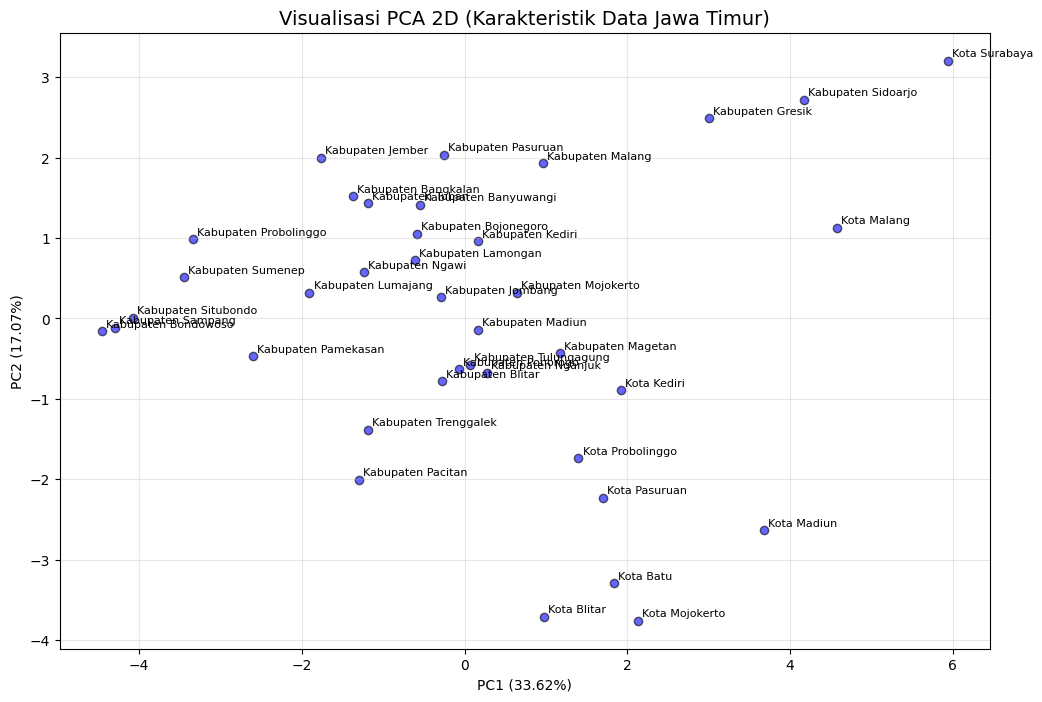

Kontribusi Variabel terhadap PC1 dan PC2 (Loadings):


,PC1,PC2
Indeks Pembangunan Manusia,0.380924,-0.108872
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,0.370525,-0.093802
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,0.352621,0.092060
Angka Melek Huruf penduduk miskin 15-55tahun,0.297549,-0.133912
Tingkat Pengangguran Terbuka,0.240863,0.242828
Ruta miskin yg menggunakan jamban,0.235180,-0.122264
Jumlah Pelanggan Air Bersih,0.201892,0.415496
Ruta miskin yg menggunakan air layak,0.193115,0.072074
Rasio Jenis Kelamin,0.185930,0.009271
PDRB Atas Dasar Harga Konstan 2010,0.145637,0.484077


In [10]:
# Inisialisasi PCA untuk 2 komponen utama (agar bisa diplot 2D)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_ready)

# Membuat DataFrame hasil PCA
pca_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

# Mengambil nama kabupaten dari df asli untuk label di grafik
pca_df['Kabupaten'] = df['Kabupaten/Kota Se Jawa Timur'].values

# 3. Visualisasi PCA 2D
plt.figure(figsize=(12, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', alpha=0.6, edgecolors='k')

# Menambahkan label teks pada setiap titik kabupaten
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, row['Kabupaten'], fontsize=8)

plt.title('Visualisasi PCA 2D (Karakteristik Data Jawa Timur)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(alpha=0.3)
plt.show()

# Opsional: Melihat variabel mana yang paling berpengaruh pada PC1 dan PC2
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=data_ready.columns)
print("Kontribusi Variabel terhadap PC1 dan PC2 (Loadings):")
display(loadings.sort_values(by='PC1', ascending=False))

# K-MEANS
-----------

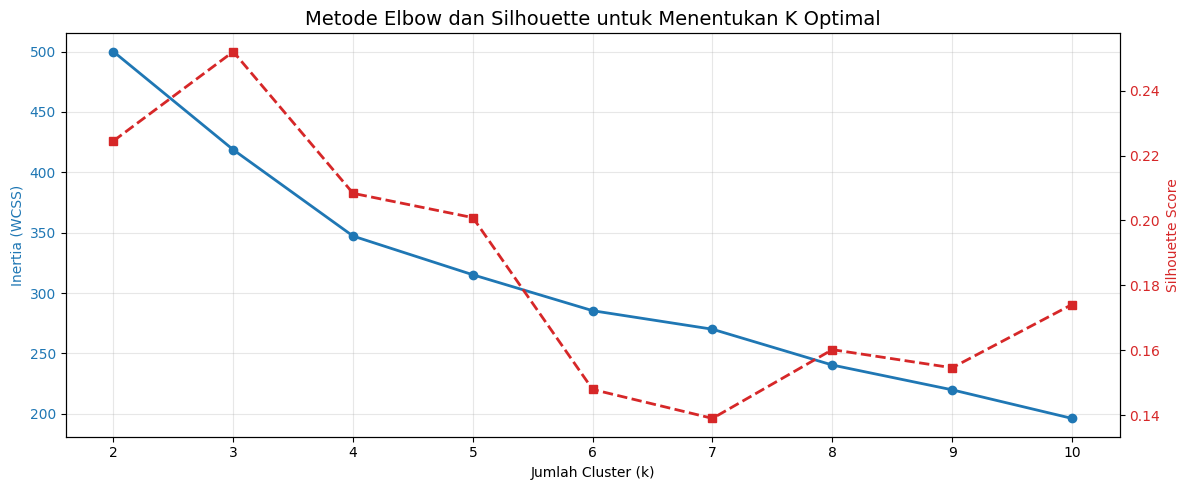

Jumlah Cluster 2: Silhouette Score = 0.2245
Jumlah Cluster 3: Silhouette Score = 0.2521
Jumlah Cluster 4: Silhouette Score = 0.2084
Jumlah Cluster 5: Silhouette Score = 0.2009
Jumlah Cluster 6: Silhouette Score = 0.1479
Jumlah Cluster 7: Silhouette Score = 0.1390
Jumlah Cluster 8: Silhouette Score = 0.1602
Jumlah Cluster 9: Silhouette Score = 0.1546
Jumlah Cluster 10: Silhouette Score = 0.1741


In [11]:
# 1. Menyiapkan Data
# Kita gunakan data_ready (data yang sudah di-scale/standarisasi di cell sebelumnya)
X = data_ready.copy()

inertia = []
silhouette_vals = []
range_k = range(2, 11) # Mencoba k dari 2 sampai 10

# 2. Iterasi untuk mencari K Optimal
for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(X, kmeans.labels_)
    silhouette_vals.append(score)

# 3. Visualisasi Elbow dan Silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Elbow (Inersia) - Kiri
color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(range_k, inertia, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot Silhouette Score - Kanan (Twin Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(range_k, silhouette_vals, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metode Elbow dan Silhouette untuk Menentukan K Optimal', fontsize=14)
fig.tight_layout()
plt.show()

# 4. Menampilkan Nilai Silhouette Score per K
for k, score in zip(range_k, silhouette_vals):
    print(f"Jumlah Cluster {k}: Silhouette Score = {score:.4f}")


### Nilai Silhouette Score tertinggi tercapai pada $k=3$ (0.2521).
Meskipun nilai inersia pada grafik Elbow terus menurun, 
puncak pada skor Silhouette di $k=3$ mengonfirmasi bahwa data secara alami 
terbagi menjadi tiga kelompok dengan pemisahan yang paling konsisten dan risiko overlap yang minimal.

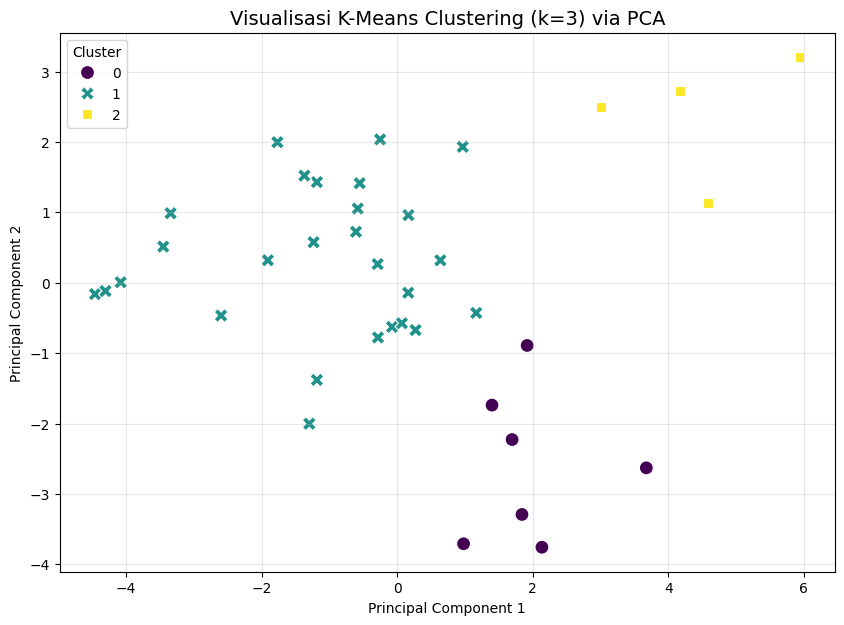

In [12]:
# 1. Menjalankan K-Means dengan k=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cluster_kmeans = kmeans_final.fit_predict(X)

# 2. Visualisasi dengan PCA (Gunakan data_pca dari cell sebelumnya)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_kmeans, 
                palette='viridis', s=100, style=cluster_kmeans)

plt.title('Visualisasi K-Means Clustering (k=3) via PCA', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
df_cluster = df.copy()

df_cluster['cluster'] = cluster_kmeans

# Ambil hanya kolom numerik
numeric_cols = df_cluster.select_dtypes(include='number')

# Hitung mean per cluster
print(numeric_cols.groupby(df_cluster['cluster']).mean())

         Tingkat Pengangguran Terbuka   Tingkat Partisipasi Angkatan Kerja   \
cluster                                                                       
0                             3.834286                            67.481429   
1                             3.346296                            70.614444   
2                             5.415000                            66.917500   

         Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan   \
cluster                                                               
0                                                45.077143            
1                                                52.825185            
2                                                42.027500            

         Jumlah Pelanggan Air Bersih   \
cluster                                 
0                        17624.000000   
1                        38547.444444   
2                       245920.250000   

         Persentase Pengeluaran Perkapita 

In [25]:
import geopandas as gpd

path_peta = "D:\PENS SMT 2\Praktikum Pemodelan Statistik\Clustering\gadm41_IDN_2.shp"
map_df = gpd.read_file(path_peta)

# Filter hanya wilayah Jawa Timur
map_jatim = map_df[map_df['NAME_1'] == 'Jawa Timur'].copy()

print(map_jatim.columns)
print(f"Jumlah wilayah di peta: {len(map_jatim)}")

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\user\AppData\Local\Temp\ipykernel_4336\8252353.py:3: SyntaxWarning: invalid escape sequence '\P'
  path_peta = "D:\PENS SMT 2\Praktikum Pemodelan Statistik\Clustering\gadm41_IDN_2.shp"


Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')
Jumlah wilayah di peta: 38


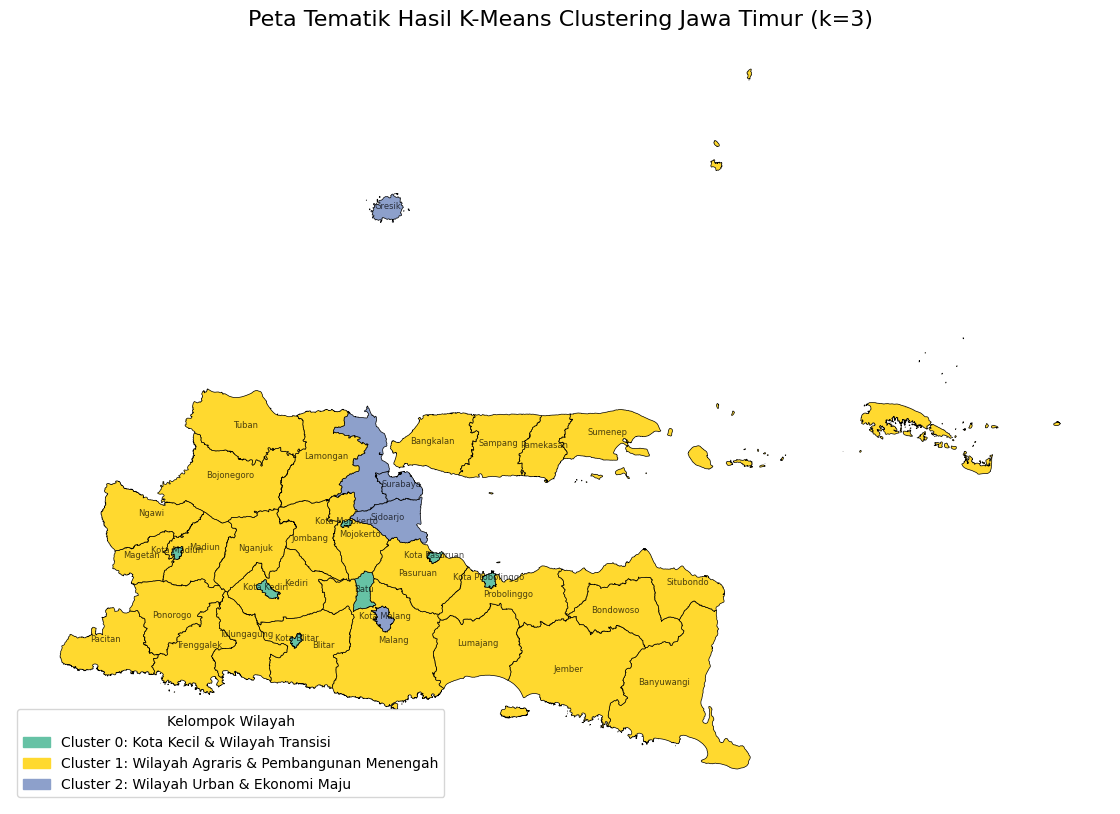

In [26]:
# =========================================================
# PETA TEMATIK K-MEANS CLUSTERING JAWA TIMUR (VERSI REVISI)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. DATA HASIL CLUSTERING
# =========================================================

# cluster_kmeans berasal dari:
# kmeans.fit_predict(X_scaled)

df_map_kmeans = pd.DataFrame({
    'Kabupaten_Ori': df['Kabupaten/Kota Se Jawa Timur'].values,
    'Cluster_ID': cluster_kmeans
})

# =========================================================
# 2. MAPPING NAMA KABUPATEN/KOTA
# =========================================================

mapping_gadm = {
    'Kabupaten Pacitan': 'Pacitan',
    'Kabupaten Ponorogo': 'Ponorogo',
    'Kabupaten Trenggalek': 'Trenggalek',
    'Kabupaten Tulungagung': 'Tulungagung',
    'Kabupaten Blitar': 'Blitar',
    'Kabupaten Kediri': 'Kediri',
    'Kabupaten Malang': 'Malang',
    'Kabupaten Lumajang': 'Lumajang',
    'Kabupaten Jember': 'Jember',
    'Kabupaten Banyuwangi': 'Banyuwangi',
    'Kabupaten Bondowoso': 'Bondowoso',
    'Kabupaten Situbondo': 'Situbondo',
    'Kabupaten Probolinggo': 'Probolinggo',
    'Kabupaten Pasuruan': 'Pasuruan',
    'Kabupaten Sidoarjo': 'Sidoarjo',
    'Kabupaten Mojokerto': 'Mojokerto',
    'Kabupaten Jombang': 'Jombang',
    'Kabupaten Nganjuk': 'Nganjuk',
    'Kabupaten Madiun': 'Madiun',
    'Kabupaten Magetan': 'Magetan',
    'Kabupaten Ngawi': 'Ngawi',
    'Kabupaten Bojonegoro': 'Bojonegoro',
    'Kabupaten Tuban': 'Tuban',
    'Kabupaten Lamongan': 'Lamongan',
    'Kabupaten Gresik': 'Gresik',
    'Kabupaten Bangkalan': 'Bangkalan',
    'Kabupaten Sampang': 'Sampang',
    'Kabupaten Pamekasan': 'Pamekasan',
    'Kabupaten Sumenep': 'Sumenep',

    'Kota Kediri': 'Kota Kediri',
    'Kota Blitar': 'Kota Blitar',
    'Kota Malang': 'Kota Malang',
    'Kota Probolinggo': 'Kota Probolinggo',
    'Kota Pasuruan': 'Kota Pasuruan',
    'Kota Mojokerto': 'Kota Mojokerto',
    'Kota Madiun': 'Kota Madiun',
    'Kota Surabaya': 'Surabaya',
    'Kota Batu': 'Batu'
}

df_map_kmeans['Kabupaten_Match'] = (
    df_map_kmeans['Kabupaten_Ori']
    .map(mapping_gadm)
)

# =========================================================
# 3. CEK DATA YANG TIDAK TERMAPPING
# =========================================================

missing = df_map_kmeans[
    df_map_kmeans['Kabupaten_Match'].isna()
]

if len(missing) > 0:
    print("Wilayah yang belum termapping:")
    print(missing[['Kabupaten_Ori']])

# =========================================================
# 4. MERGE DENGAN SHAPEFILE
# =========================================================

merged_kmeans = map_jatim.merge(
    df_map_kmeans,
    left_on='NAME_2',
    right_on='Kabupaten_Match',
    how='left'
)

# =========================================================
# 5. LABEL INTERPRETASI CLUSTER
# =========================================================

# Berdasarkan hasil centroid statistik
cluster_desc = {
    0: 'Kota Kecil & Wilayah Transisi',
    1: 'Wilayah Agraris & Pembangunan Menengah',
    2: 'Wilayah Urban & Ekonomi Maju'
}

merged_kmeans['Karakteristik'] = (
    merged_kmeans['Cluster_ID']
    .map(cluster_desc)
)

# =========================================================
# 6. WARNA CUSTOM (NETRAL & TIDAK BIAS)
# =========================================================

cluster_colors = {
    0: '#66c2a5',   # hijau tosca
    1: '#ffd92f',   # kuning
    2: '#8da0cb'    # biru ungu
}

merged_kmeans['color'] = (
    merged_kmeans['Cluster_ID']
    .map(cluster_colors)
)

# =========================================================
# 7. PLOT PETA
# =========================================================

fig, ax = plt.subplots(figsize=(15, 10))

merged_kmeans.plot(
    color=merged_kmeans['color'],
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Data Tidak Cocok"
    }
)

# =========================================================
# 8. LABEL NAMA WILAYAH
# =========================================================

for idx, row in merged_kmeans.iterrows():

    if row['geometry'] is not None:

        # lebih aman daripada centroid
        point = row['geometry'].representative_point()

        plt.annotate(
            text=row['NAME_2'],
            xy=(point.x, point.y),
            horizontalalignment='center',
            fontsize=6,
            alpha=0.7
        )

# =========================================================
# 9. LEGEND MANUAL
# =========================================================

import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(
        color='#66c2a5',
        label='Cluster 0: Kota Kecil & Wilayah Transisi'
    ),

    mpatches.Patch(
        color='#ffd92f',
        label='Cluster 1: Wilayah Agraris & Pembangunan Menengah'
    ),

    mpatches.Patch(
        color='#8da0cb',
        label='Cluster 2: Wilayah Urban & Ekonomi Maju'
    )
]

plt.legend(
    handles=legend_handles,
    title='Kelompok Wilayah',
    loc='lower left'
)

# =========================================================
# 10. JUDUL & TAMPILKAN
# =========================================================

plt.title(
    'Peta Tematik Hasil K-Means Clustering Jawa Timur (k=3)',
    fontsize=16
)

plt.axis('off')

plt.show()

# GMM
---------

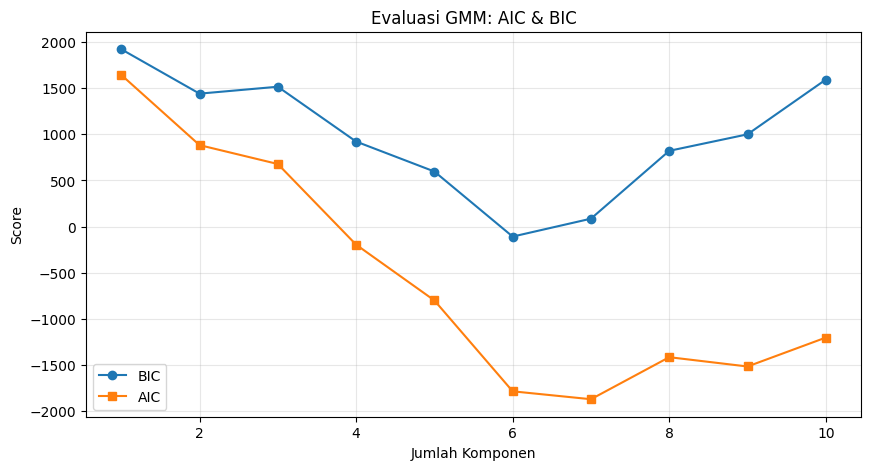

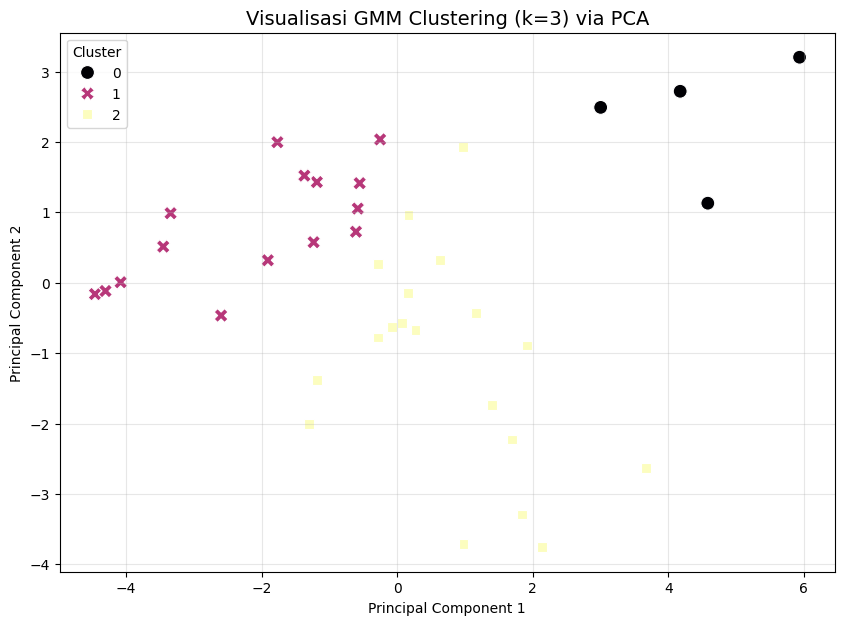

In [15]:
from sklearn.mixture import GaussianMixture

# 1. Mencari K optimal untuk GMM menggunakan BIC & AIC
n_components = range(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X) for n in n_components]

plt.figure(figsize=(10, 5))
plt.plot(n_components, [m.bic(X) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC', marker='s')
plt.legend(loc='best')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Score')
plt.title('Evaluasi GMM: AIC & BIC')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Implementasi GMM dengan k=3 (sesuai konsistensi sebelumnya)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
cluster_gmm = gmm.fit_predict(X)

# Visualisasi GMM Clustering (k=3) via PCA
plt.figure(figsize=(10, 7))

# Plotting menggunakan data PCA yang sudah ada dan label dari GMM
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_gmm, 
                palette='magma', s=100, style=cluster_gmm)

plt.title('Visualisasi GMM Clustering (k=3) via PCA', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
df_cluster = df.copy()

df_cluster['cluster'] = cluster_gmm

# Ambil hanya kolom numerik
numeric_cols = df_cluster.select_dtypes(include='number')

# Hitung mean per cluster
print(numeric_cols.groupby(df_cluster['cluster']).mean())

         Tingkat Pengangguran Terbuka   Tingkat Partisipasi Angkatan Kerja   \
cluster                                                                       
0                             5.415000                            66.917500   
1                             3.427333                            69.802667   
2                             3.462105                            70.101053   

         Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan   \
cluster                                                               
0                                                42.027500            
1                                                55.330000            
2                                                47.993158            

         Jumlah Pelanggan Air Bersih   \
cluster                                 
0                       245920.250000   
1                        30261.333333   
2                        37380.473684   

         Persentase Pengeluaran Perkapita 

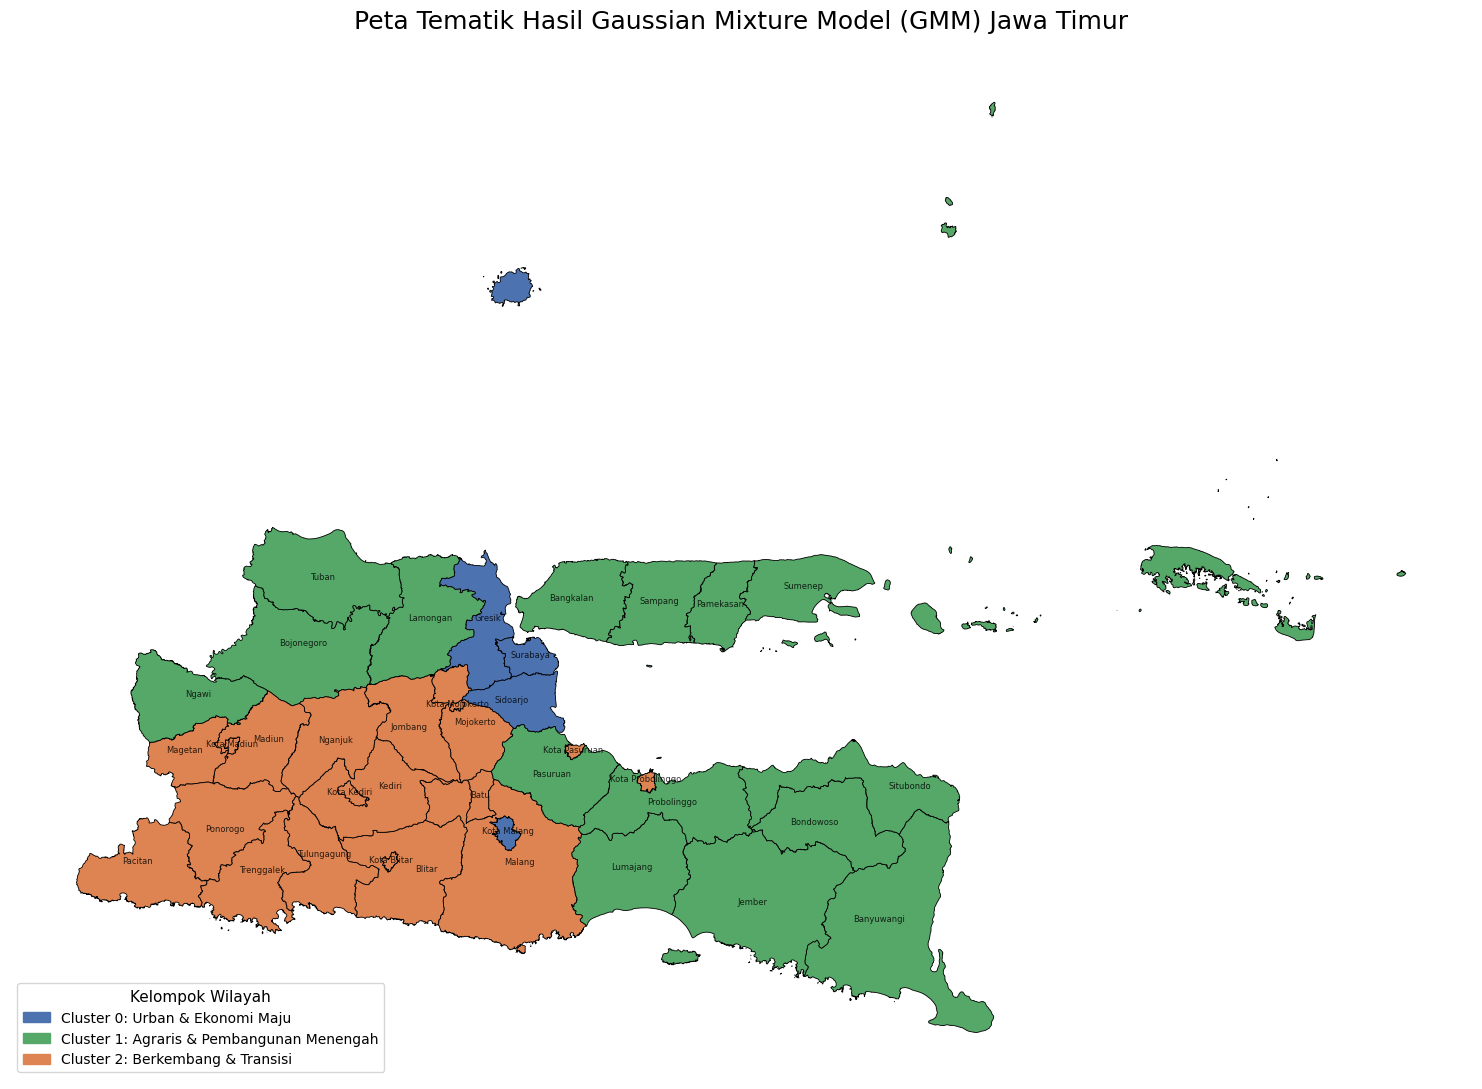

In [32]:
# =========================================================
# PETA TEMATIK HASIL GAUSSIAN MIXTURE MODEL (GMM)
# JAWA TIMUR
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================================================
# 1. DATA HASIL CLUSTERING GMM
# =========================================================

# cluster_gmm berasal dari:
# gmm.fit_predict(X_scaled)

df_map_gmm = pd.DataFrame({
    'Kabupaten_Ori': df['Kabupaten/Kota Se Jawa Timur'].values,
    'Cluster_ID': cluster_gmm
})

# =========================================================
# 2. MAPPING NAMA KABUPATEN/KOTA
# =========================================================

mapping_gadm = {

    # Kabupaten
    'Kabupaten Pacitan': 'Pacitan',
    'Kabupaten Ponorogo': 'Ponorogo',
    'Kabupaten Trenggalek': 'Trenggalek',
    'Kabupaten Tulungagung': 'Tulungagung',
    'Kabupaten Blitar': 'Blitar',
    'Kabupaten Kediri': 'Kediri',
    'Kabupaten Malang': 'Malang',
    'Kabupaten Lumajang': 'Lumajang',
    'Kabupaten Jember': 'Jember',
    'Kabupaten Banyuwangi': 'Banyuwangi',
    'Kabupaten Bondowoso': 'Bondowoso',
    'Kabupaten Situbondo': 'Situbondo',
    'Kabupaten Probolinggo': 'Probolinggo',
    'Kabupaten Pasuruan': 'Pasuruan',
    'Kabupaten Sidoarjo': 'Sidoarjo',
    'Kabupaten Mojokerto': 'Mojokerto',
    'Kabupaten Jombang': 'Jombang',
    'Kabupaten Nganjuk': 'Nganjuk',
    'Kabupaten Madiun': 'Madiun',
    'Kabupaten Magetan': 'Magetan',
    'Kabupaten Ngawi': 'Ngawi',
    'Kabupaten Bojonegoro': 'Bojonegoro',
    'Kabupaten Tuban': 'Tuban',
    'Kabupaten Lamongan': 'Lamongan',
    'Kabupaten Gresik': 'Gresik',
    'Kabupaten Bangkalan': 'Bangkalan',
    'Kabupaten Sampang': 'Sampang',
    'Kabupaten Pamekasan': 'Pamekasan',
    'Kabupaten Sumenep': 'Sumenep',

    # Kota
    'Kota Kediri': 'Kota Kediri',
    'Kota Blitar': 'Kota Blitar',
    'Kota Malang': 'Kota Malang',
    'Kota Probolinggo': 'Kota Probolinggo',
    'Kota Pasuruan': 'Kota Pasuruan',
    'Kota Mojokerto': 'Kota Mojokerto',
    'Kota Madiun': 'Kota Madiun',
    'Kota Surabaya': 'Surabaya',
    'Kota Batu': 'Batu'
}

df_map_gmm['Kabupaten_Match'] = (
    df_map_gmm['Kabupaten_Ori']
    .map(mapping_gadm)
)

# =========================================================
# 3. CEK DATA YANG TIDAK TERMAPPING
# =========================================================

missing = df_map_gmm[
    df_map_gmm['Kabupaten_Match'].isna()
]

if len(missing) > 0:

    print("=" * 50)
    print("WILAYAH YANG BELUM TERMAPPING")
    print("=" * 50)

    print(missing[['Kabupaten_Ori']])

# =========================================================
# 4. MERGE DENGAN SHAPEFILE
# =========================================================

merged_gmm = map_jatim.merge(
    df_map_gmm,
    left_on='NAME_2',
    right_on='Kabupaten_Match',
    how='left'
)

# =========================================================
# 5. INTERPRETASI CLUSTER BERDASARKAN HASIL STATISTIK
# =========================================================

# INTERPRETASI:
#
# Cluster 0:
# - IPM tertinggi
# - PDRB tertinggi
# - Upah tertinggi
# - Air bersih tinggi
# -> Urban & ekonomi maju
#
# Cluster 1:
# - Produksi padi tertinggi
# - IPM terendah
# - Pernikahan dini tinggi
# -> Agraris & pembangunan menengah ke bawah
#
# Cluster 2:
# - Nilai menengah/transisi
# -> Wilayah berkembang/transisi

cluster_desc = {
    0: 'Wilayah Urban & Ekonomi Maju',
    1: 'Wilayah Agraris & Pembangunan Menengah',
    2: 'Wilayah Berkembang & Transisi'
}

merged_gmm['Karakteristik'] = (
    merged_gmm['Cluster_ID']
    .map(cluster_desc)
)

# =========================================================
# 6. WARNA CLUSTER (NETRAL & SESUAI KARAKTER)
# =========================================================

# Biru   -> urban/maju
# Hijau  -> agraris
# Oranye -> transisi

cluster_colors = {
    0: '#4C72B0',   # biru
    1: '#55A868',   # hijau
    2: '#DD8452'    # oranye
}

merged_gmm['color'] = (
    merged_gmm['Cluster_ID']
    .map(cluster_colors)
)

# =========================================================
# 7. PLOT PETA
# =========================================================

fig, ax = plt.subplots(figsize=(16, 11))

merged_gmm.plot(
    color=merged_gmm['color'],
    edgecolor='black',
    linewidth=0.6,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Data Tidak Cocok"
    }
)

# =========================================================
# 8. LABEL NAMA WILAYAH
# =========================================================

for idx, row in merged_gmm.iterrows():

    geom = row['geometry']

    if geom is not None:

        # Jika MultiPolygon, ambil polygon terbesar
        if geom.geom_type == 'MultiPolygon':

            largest_polygon = max(
                geom.geoms,
                key=lambda a: a.area
            )

            point = largest_polygon.representative_point()

        else:

            point = geom.representative_point()

        plt.annotate(
            text=row['NAME_2'],
            xy=(point.x, point.y),
            horizontalalignment='center',
            fontsize=6,
            alpha=0.8
        )

# =========================================================
# 9. LEGEND MANUAL
# =========================================================

legend_handles = [

    mpatches.Patch(
        color='#4C72B0',
        label='Cluster 0: Urban & Ekonomi Maju'
    ),

    mpatches.Patch(
        color='#55A868',
        label='Cluster 1: Agraris & Pembangunan Menengah'
    ),

    mpatches.Patch(
        color='#DD8452',
        label='Cluster 2: Berkembang & Transisi'
    )
]

plt.legend(
    handles=legend_handles,
    title='Kelompok Wilayah',
    loc='lower left',
    fontsize=10,
    title_fontsize=11
)

# =========================================================
# 10. JUDUL
# =========================================================

plt.title(
    'Peta Tematik Hasil Gaussian Mixture Model (GMM) Jawa Timur',
    fontsize=18,
    pad=20
)

plt.axis('off')

plt.tight_layout()

plt.show()

# EVALUASI MODEL
-----

In [17]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def calculate_clustering_metrics(X, labels, name):
    sil = silhouette_score(X, labels)
    chi = calinski_harabasz_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    
    wcss = 0
    centroids = []
    for i in np.unique(labels):
        cluster_points = X[labels == i]
        centroid = cluster_points.mean(axis=0)
        centroids.append(centroid)
        wcss += np.sum((cluster_points - centroid) ** 2)
    
    global_mean = X.mean(axis=0)
    tss = np.sum((X - global_mean) ** 2)
    bss = tss - wcss
    bss_tss_ratio = bss / tss
    
    return {
        'Metode': name,
        'Silhouette ↑': sil,
        'CHI ↑': chi,
        'DBI ↓': dbi,
        'WCSS ↓': wcss,
        'BSS/TSS ↑': bss_tss_ratio
    }

X_eval = data_ready.values

results = []
results.append(calculate_clustering_metrics(X_eval, cluster_kmeans, 'K-Means'))
results.append(calculate_clustering_metrics(X_eval, cluster_gmm, 'GMM'))

df_metrik = pd.DataFrame(results)

print("Tabel Evaluasi Perbandingan Metode Clustering (k=3):")
display(df_metrik.style.highlight_max(subset=['Silhouette ↑', 'CHI ↑', 'BSS/TSS ↑'], color='green')
                .highlight_min(subset=['DBI ↓', 'WCSS ↓'], color='green'))

Tabel Evaluasi Perbandingan Metode Clustering (k=3):


,Metode,Silhouette ↑,CHI ↑,DBI ↓,WCSS ↓,BSS/TSS ↑
0,K-Means,0.252054,9.501384,1.283093,418.682238,0.351885
1,GMM,0.177426,9.347801,1.586199,421.077310,0.348178


# Tabel Hasil Cluster
-------------

In [18]:
hasil_cluster = df.copy()
hasil_cluster['KMeans'] = cluster_kmeans + 1
hasil_cluster['GMM'] = cluster_gmm + 1
display(hasil_cluster)

,Kabupaten/Kota Se Jawa Timur,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,...,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010,KMeans,GMM
0,Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,...,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8,2,3
1,Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,...,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1,2,3
2,Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,...,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5,2,3
3,Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,...,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8,2,3
4,Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,...,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1,2,3
5,Kabupaten Kediri,3.58,71.76,53.44,180058,46.56,1837409,783578,90660,3.97,...,85.95,0.299,0.22,8.01,72.80,17.41,222837.82,29193.7,2,3
6,Kabupaten Malang,3.70,70.07,47.14,125530,52.86,2095671,1354311,143010,6.56,...,77.25,0.382,0.40,7.27,71.24,16.63,281072.26,68379.7,2,3
7,Kabupaten Lumajang,2.73,66.14,57.99,33005,42.01,1763308,539800,44402,2.63,...,82.51,0.295,0.20,6.22,67.04,15.49,283894.22,22563.4,2,2
8,Kabupaten Jember,3.69,67.16,55.11,44998,44.89,1825153,1224493,120140,6.17,...,87.76,0.301,0.24,6.18,69.01,15.26,616858.41,54200.0,2,2
9,Kabupaten Banyuwangi,3.95,72.13,49.57,62239,50.43,1991869,870242,72007,4.07,...,77.66,0.313,0.34,7.13,71.85,17.85,445253.86,55274.0,2,2


# Menampilkan Jumlah Anggota Cluster Tiap Model
--------

In [19]:
print("KMeans:\n", hasil_cluster['KMeans'].value_counts(), "\n")
print("GMM:\n", hasil_cluster['GMM'].value_counts())

KMeans:
 KMeans
2    27
1     7
3     4
Name: count, dtype: int64 

GMM:
 GMM
3    19
2    15
1     4
Name: count, dtype: int64


In [20]:
berbeda = hasil_cluster[
    hasil_cluster['KMeans'] != hasil_cluster['GMM']
]

print(f"Ditemukan {len(berbeda)} wilayah dengan klasifikasi berbeda:")
display(berbeda[['Kabupaten/Kota Se Jawa Timur', 'KMeans', 'GMM']])

Ditemukan 23 wilayah dengan klasifikasi berbeda:


,Kabupaten/Kota Se Jawa Timur,KMeans,GMM
0,Kabupaten Pacitan,2,3
1,Kabupaten Ponorogo,2,3
2,Kabupaten Trenggalek,2,3
3,Kabupaten Tulungagung,2,3
4,Kabupaten Blitar,2,3
5,Kabupaten Kediri,2,3
6,Kabupaten Malang,2,3
14,Kabupaten Sidoarjo,3,1
15,Kabupaten Mojokerto,2,3
16,Kabupaten Jombang,2,3


# Menampilkan Centroid K-MEANS
---------

In [21]:
# Mendapatkan koordinat centroid dari model KMeans yang sudah dilatih
# kmeans_final adalah nama variabel model KMeans k=3 Anda
centroids = kmeans_final.cluster_centers_

# Membuat DataFrame agar mudah dibaca
# data_ready.columns adalah daftar 17 variabel yang Anda gunakan
df_centroids = pd.DataFrame(centroids, columns=data_ready.columns)

# Menambahkan label Cluster agar jelas
df_centroids.index = [f'Centroid Cluster {i+1}' for i in range(len(centroids))]

# Menampilkan Tabel Centroid
print("Tabel Centroid K-Means (Skala Standardisasi):")
display(df_centroids)

Tabel Centroid K-Means (Skala Standardisasi):


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,Rasio Jenis Kelamin,Angka Melek Huruf penduduk miskin 15-55tahun,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Indeks Pembangunan Manusia,Angka Kesakitan,PDRB Atas Dasar Harga Konstan 2010
Centroid Cluster 1,0.169175,-0.632749,-0.849107,0.910413,0.441636,-1.679943,-1.088503,0.269778,0.781356,-0.115183,0.539210,-1.262857,-0.270192,-0.947746,1.109108,0.104246,-0.904697
Centroid Cluster 2,-0.288607,0.282184,-0.064758,-0.450251,-0.407847,0.285534,0.460187,-0.150551,-0.304472,-0.179316,-0.222431,0.364077,0.026494,0.282470,-0.530355,0.144591,-0.018896
Centroid Cluster 3,1.652039,-0.797433,1.923051,1.445973,1.980105,1.012546,-1.201383,0.544106,0.687812,1.411953,0.557794,-0.247522,0.294001,-0.248115,1.638959,-1.158420,1.710769


In [22]:
# Melakukan Inverse Transform pada koordinat centroid
# Kita menggunakan scaler yang Anda gunakan sebelumnya (misal: scaler_std)
centroids_asli = scaler.inverse_transform(kmeans_final.cluster_centers_)

# Membuat DataFrame skala asli
# data_final.columns adalah nama kolom sebelum di-scaling
df_centroids_asli = pd.DataFrame(centroids_asli, columns=data_final.columns)

# Menambahkan label Cluster
df_centroids_asli.index = [f'Centroid Cluster {i+1}' for i in range(len(centroids_asli))]

# Menampilkan Tabel Centroid Skala Asli
print("Tabel Centroid K-Means (Skala Data Asli):")
display(df_centroids_asli)

# 5. Opsional: Transpose tabel agar lebih mudah dibaca jika variabelnya banyak
# display(df_centroids_asli.T)

Tabel Centroid K-Means (Skala Data Asli):


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,Rasio Jenis Kelamin,Angka Melek Huruf penduduk miskin 15-55tahun,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Indeks Pembangunan Manusia,Angka Kesakitan,PDRB Atas Dasar Harga Konstan 2010
Centroid Cluster 1,3.834286,67.481429,9.576765,54.922857,14.655515,0.399026,2.452756,97.882857,4.601078,67.507143,4.453294,3.867948,0.315429,0.161363,78.091429,17.538571,9.253400
Centroid Cluster 2,3.346296,70.614444,10.309324,47.174815,14.484877,1.318576,3.130738,96.818519,4.549039,66.603704,4.261647,4.428965,0.325852,0.356287,70.491852,17.701481,10.113398
Centroid Cluster 3,5.415000,66.917500,12.165876,57.972500,14.964552,1.658709,2.403340,98.577500,4.596595,89.020000,4.457970,4.218067,0.335250,0.272218,80.547500,12.440000,11.792681
